In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from transformers import ViTImageProcessorFast, ViTForImageClassification
from torch.utils.data import DataLoader,random_split
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm


In [21]:
# Setup
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")  # Use Apple Metal
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU
else:
    device = torch.device("cpu")   # Fallback to CPU
print(f"Using device: {device}")

MODEL_NAME = 'google/vit-base-patch16-224'
SEED = 11
FINETUNED_MODEL_DIR="./models/"

Using device: mps


In [26]:
processor = ViTImageProcessorFast.from_pretrained(MODEL_NAME)

# Create a custom transform function that works with ImageFolder
def vit_transform(image):
    """Transform function that processes PIL images using ViT processor."""
    inputs = processor(images=image, return_tensors="pt")
    return inputs['pixel_values'].squeeze(0)  # Remove batch dimension

# Create dataset with custom transform
dataset = datasets.ImageFolder(root='../data', transform=vit_transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 25115.59it/s]


#### C. Visualización de imágenes

A continuación, se muestra el resultado de una imágen cualquiera después del preprocesamiento de los datos.

In [14]:
def process_image_vit(pil_image, processor):
    """Processes a PIL image using the ViT processor."""
    inputs = processor(images=pil_image, return_tensors="pt")
    return inputs['pixel_values'].squeeze(0)  # Remove batch dimension

def denormalize(tensor_image, std, mean):
    """Converts a normalized tensor back to a visible image."""
    # Move dimensions from (C, H, W) to (H, W, C) for matplotlib
    img = tensor_image.permute(1, 2, 0).cpu().numpy()
    # De-normalize
    img = (img * std + mean)
    # Ensure values are in [0, 1] range for visualization
    img = np.clip(img, 0, 1)
    return img

def get_sample_from_each_class(dataset, class_to_idx):
    """Gets a sample image from each class."""
    samples = {}
    
    # Iterate through dataset to find the first image of each class
    for img_path, class_idx in dataset.samples:
        class_name = dataset.classes[class_idx]
        if class_name not in samples:
            # Load the image
            img = dataset.loader(img_path)
            samples[class_name] = (img, class_idx)
        
        # If we already have a sample from each class, stop
        if len(samples) == len(class_to_idx):
            break
    
    return samples

Classes found: ['Buffalo', 'Elephant', 'Rhino', 'Zebra']


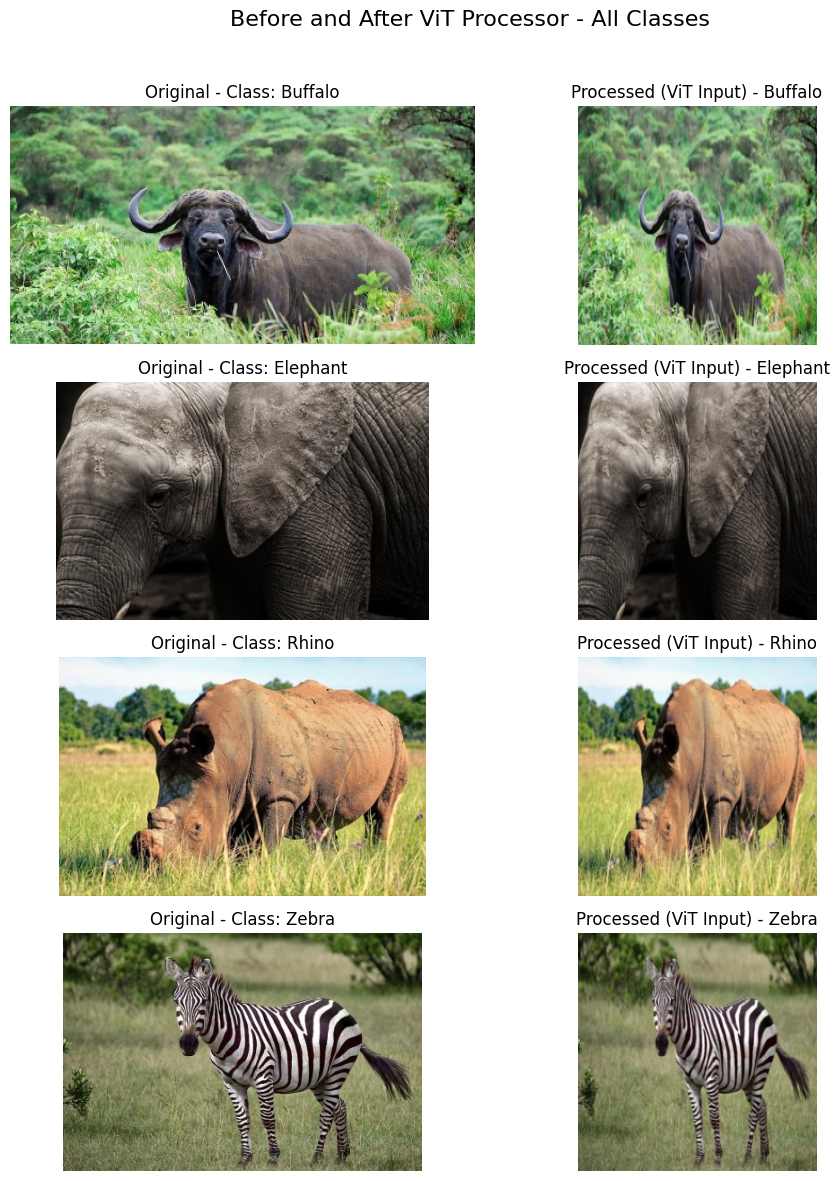

In [16]:
# Dataset without transformations to get original images
dataset_original = datasets.ImageFolder(root='../data')

# Mapping from indices to class names
idx_to_class = {v: k for k, v in dataset_original.class_to_idx.items()}

# Get normalization parameters from processor
mean = np.array(processor.image_mean)
std = np.array(processor.image_std)

# Get available classes
class_names = dataset_original.classes
num_classes = len(class_names)
print(f"Classes found: {class_names}")


# Get samples from each class
samples_per_class = get_sample_from_each_class(dataset_original, dataset_original.class_to_idx)

# Create a figure to show the images
fig, axes = plt.subplots(num_classes, 2, figsize=(10, 3*num_classes))
fig.suptitle('Before and After ViT Processor - All Classes', fontsize=16)

for i, (class_name, (original_img, label_idx)) in enumerate(samples_per_class.items()):
    processed_tensor = process_image_vit(original_img, processor)

    ax = axes[i, 0]
    ax.imshow(original_img)
    ax.set_title(f'Original - Class: {class_name}')
    ax.axis('off')

    ax = axes[i, 1]
    visible_image = denormalize(processed_tensor, std, mean)
    ax.imshow(visible_image)
    ax.set_title(f'Processed (ViT Input) - {class_name}')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Entrenamiento del Modelo

In [ ]:
labels = dataset.classes
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
def collate_fn(batch):
    # item[0] is now directly the tensor from vit_transform, item[1] is the label
    pixel_values = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [23]:
model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

In [34]:
num_epochs = 3
best_val_accuracy = 0.0

print("Starting fine-tuning process...")
print("=" * 60)

for epoch in range(num_epochs):
    print(f"\n📚 Epoch {epoch + 1}/{num_epochs}")
    
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    
    # Training progress bar
    train_pbar = tqdm(train_loader, desc="Training", 
                      bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}')
    
    for batch in train_pbar:
        pixel_values = batch['pixel_values'].to(device)
        labels_batch = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels_batch)
        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        
        # Update progress bar with current loss
        current_avg_loss = total_train_loss / (train_pbar.n + 1)
        train_pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Avg Loss': f'{current_avg_loss:.4f}'
        })

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_correct = 0
    total_val_samples = 0
    
    # Validation progress bar
    val_pbar = tqdm(val_loader, desc="🔍 Validation", 
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}')
    
    with torch.no_grad():
        for batch in val_pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels_batch = batch['labels'].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            total_val_correct += (predictions == labels_batch).sum().item()
            total_val_samples += labels_batch.size(0)
            
            # Update validation progress bar with current accuracy
            current_accuracy = 100.0 * total_val_correct / total_val_samples
            val_pbar.set_postfix({
                'Accuracy': f'{current_accuracy:.2f}%'
            })

    val_accuracy = total_val_correct / total_val_samples
    
    # Print epoch summary
    print(f"\n Epoch {epoch + 1} Summary:")
    print(f"   Training Loss: {avg_train_loss:.4f}")
    print(f"   Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

    # Save the best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        print(f"   New best accuracy! Saving model...")
        model.save_pretrained(FINETUNED_MODEL_DIR)
        processor.save_pretrained(FINETUNED_MODEL_DIR)
    else:
        print(f"   No improvement. Best remains: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")

print(f"\n{'='*60}")
print(f"Fine-tuning completed!")
print(f"Best model saved to: '{FINETUNED_MODEL_DIR}'")
print(f"Best validation accuracy: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
print(f"{'='*60}")

Starting fine-tuning process...

📚 Epoch 1/3


🔍 Validation: 100%|██████████| 19/19 [00:10<00:00,  1.76it/s] , Accuracy=99.83%



 Epoch 1 Summary:
   Training Loss: 0.0943
   Validation Accuracy: 0.9983 (99.83%)
   New best accuracy! Saving model...

📚 Epoch 2/3


🔍 Validation: 100%|██████████| 19/19 [00:10<00:00,  1.80it/s] , Accuracy=99.83%



 Epoch 2 Summary:
   Training Loss: 0.0083
   Validation Accuracy: 0.9983 (99.83%)
   No improvement. Best remains: 0.9983 (99.83%)

📚 Epoch 3/3


🔍 Validation: 100%|██████████| 19/19 [00:10<00:00,  1.83it/s] , Accuracy=99.83%


 Epoch 3 Summary:
   Training Loss: 0.0035
   Validation Accuracy: 0.9983 (99.83%)
   No improvement. Best remains: 0.9983 (99.83%)

Fine-tuning completed!
Best model saved to: './models/'
Best validation accuracy: 0.9983 (99.83%)


In [45]:
# Create test loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

def evaluate_vit_model(model, test_loader):
    """
    Comprehensive evaluation of the fine-tuned ViT model on test dataset
    """
    model.eval()
    
    all_predictions = []
    all_targets = []
    all_probabilities = []
    correct = 0
    total = 0
    
    print("🧪 Evaluating model on test dataset...")
    
    # Test progress bar
    test_pbar = tqdm(test_loader, desc="🔍 Testing", 
                     bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}')
    
    with torch.no_grad():
        for batch in test_pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels_batch = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            
            # Get predictions and probabilities
            probabilities = torch.nn.functional.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=-1)
            
            # Calculate accuracy for this batch
            correct += (predictions == labels_batch).sum().item()
            total += labels_batch.size(0)
            
            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            # Update progress bar
            current_accuracy = 100.0 * correct / total
            test_pbar.set_postfix({'Accuracy': f'{current_accuracy:.2f}%'})
    
    # Calculate final metrics
    final_accuracy = correct / total
    
    print(f"\n📊 Test Results:")
    print(f"   Total samples: {total}")
    print(f"   Correct predictions: {correct}")
    print(f"   Test Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
    
    return all_predictions, all_targets, all_probabilities, final_accuracy

In [46]:
model = ViTForImageClassification.from_pretrained(FINETUNED_MODEL_DIR)
model.to(device)
predictions, targets, probabilities, final_accuracy = evaluate_vit_model(model, test_loader)

🧪 Evaluating model on test dataset...


🔍 Testing: 100%|██████████| 19/19 [00:10<00:00,  1.88it/s] , Accuracy=99.17%


📊 Test Results:
   Total samples: 600
   Correct predictions: 595
   Test Accuracy: 0.9917 (99.17%)



 Detailed Classification Analysis

 Classification Report:
              precision    recall  f1-score   support

     Buffalo     0.9853    0.9926    0.9889       135
    Elephant     0.9865    0.9932    0.9898       147
       Rhino     0.9938    0.9877    0.9907       162
       Zebra     1.0000    0.9936    0.9968       156

    accuracy                         0.9917       600
   macro avg     0.9914    0.9918    0.9916       600
weighted avg     0.9917    0.9917    0.9917       600



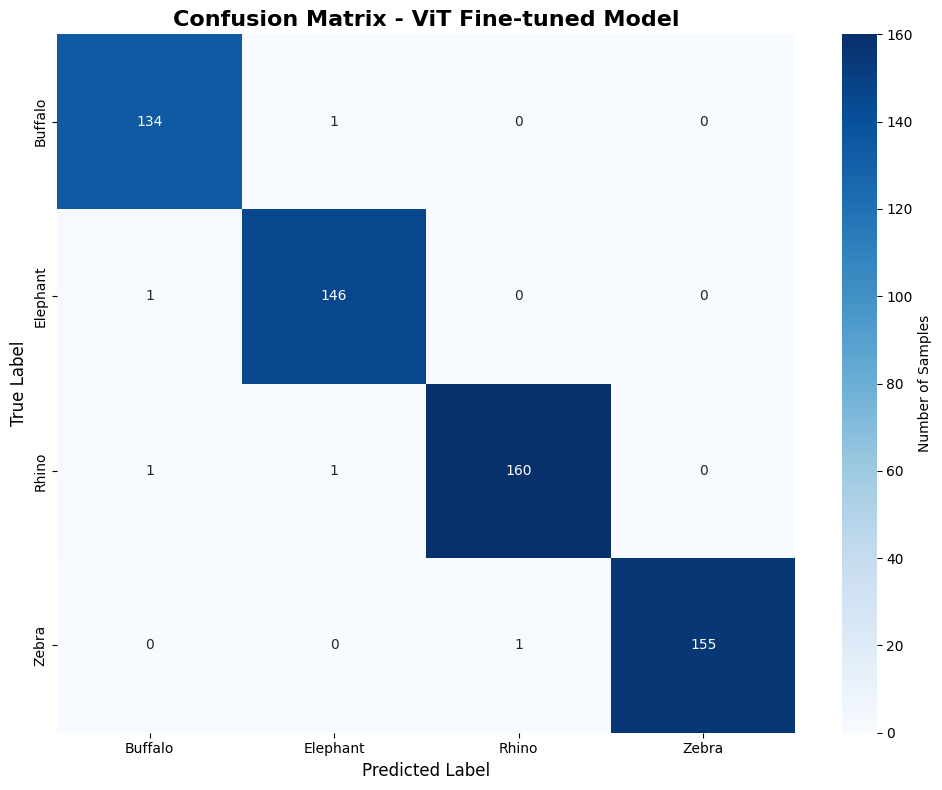


 Per-Class Accuracy:
   Buffalo     : 0.9926 ( 99.26%) [134/135]
   Elephant    : 0.9932 ( 99.32%) [146/147]
   Rhino       : 0.9877 ( 98.77%) [160/162]
   Zebra       : 0.9936 ( 99.36%) [155/156]


In [53]:
def detailed_analysis(predictions, targets, class_names):
    """
    Detailed analysis with confusion matrix and classification report
    """
    print(" Detailed Classification Analysis")
    print("=" * 50)
    
    # Classification report
    print("\n Classification Report:")
    report = classification_report(targets, predictions, target_names=class_names, digits=4)
    print(report)
    
    # Confusion matrix
    cm = confusion_matrix(targets, predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Number of Samples'})
    plt.title('Confusion Matrix - ViT Fine-tuned Model', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Per-class accuracy
    print("\n Per-Class Accuracy:")
    for i, class_name in enumerate(class_names):
        class_mask = (np.array(targets) == i)
        if class_mask.sum() > 0:
            class_predictions = np.array(predictions)[class_mask]
            class_targets = np.array(targets)[class_mask]
            class_accuracy = (class_predictions == class_targets).mean()
            total_samples = class_mask.sum()
            correct_samples = (class_predictions == class_targets).sum()
            
            print(f"   {class_name:12}: {class_accuracy:.4f} ({class_accuracy*100:6.2f}%) "
                  f"[{correct_samples:3d}/{total_samples:3d}]")
    
    return cm


# Run detailed analysis
print("\n" + "="*60)
confusion_matrix_result = detailed_analysis(predictions, targets, dataset.classes)

Found 5 misclassified samples
Error rate: 0.83%
Showing 5 misclassified samples:
   Sample 1: Buffalo -> Elephant (39.4%)
   Sample 2: Elephant -> Buffalo (84.5%)
   Sample 3: Zebra -> Rhino (43.5%)
   Sample 4: Rhino -> Elephant (57.7%)
   Sample 5: Rhino -> Buffalo (52.3%)


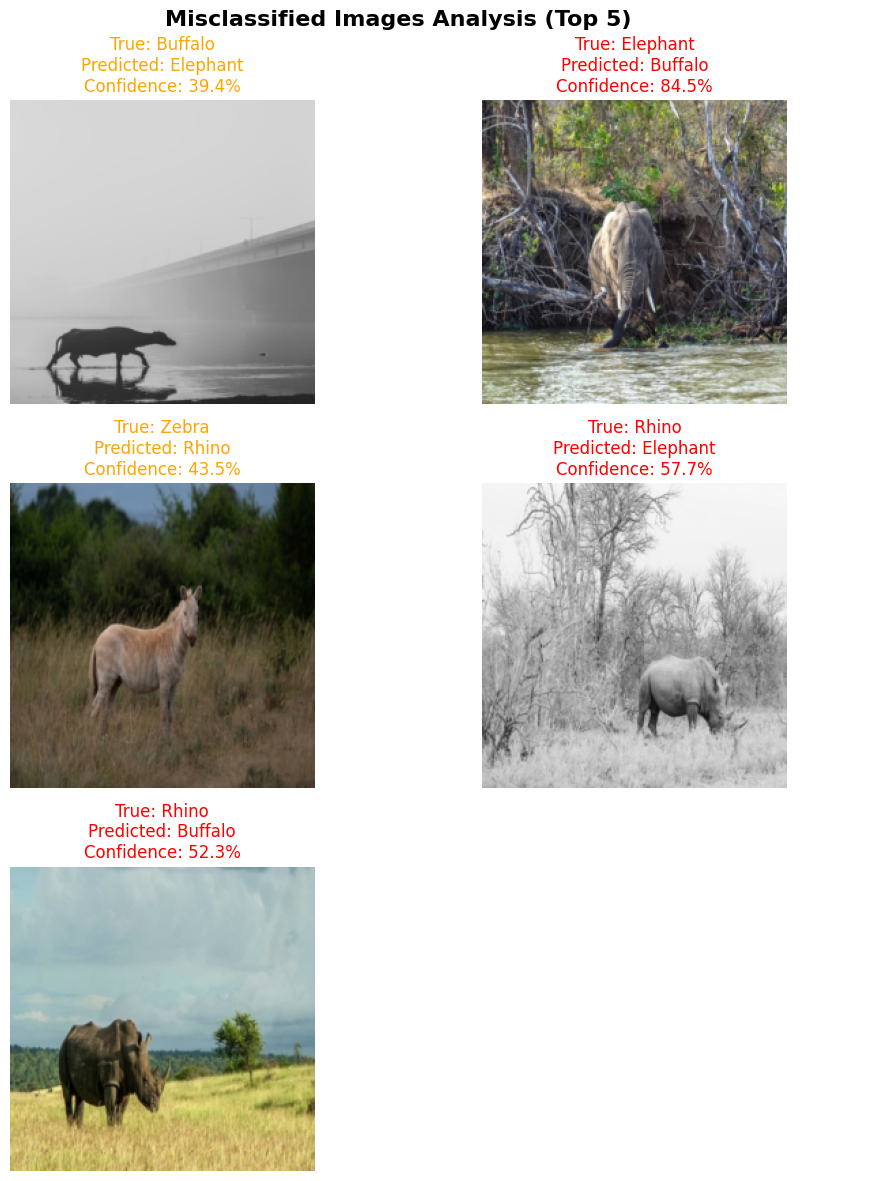

In [56]:
def visualize_misclassified_images(test_dataset, predictions, targets, probabilities, class_names, max_images=10):
    """
    Visualize misclassified images with their true and predicted labels
    """
    # Find misclassified indices
    misclassified_indices = []
    predictions_array = np.array(predictions)
    targets_array = np.array(targets)
    
    for i in range(len(predictions)):
        if predictions_array[i] != targets_array[i]:
            misclassified_indices.append(i)
    
    print(f"Found {len(misclassified_indices)} misclassified samples")
    print(f"Error rate: {len(misclassified_indices)/len(predictions)*100:.2f}%")
    
    if len(misclassified_indices) == 0:
        print("Perfect classification! No errors to visualize.")
        return
    
    # Select up to max_images samples
    num_to_show = min(max_images, len(misclassified_indices))
    selected_indices = misclassified_indices[:num_to_show]
    
    # Calculate grid dimensions
    cols = 2  # 2 images per row
    rows = (num_to_show + cols - 1) // cols  # Ceiling division
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    print(f"Showing {num_to_show} misclassified samples:")
    
    for idx, sample_idx in enumerate(selected_indices):
        # Get the image and true label from test_dataset
        image_tensor, true_label = test_dataset[sample_idx]
        
        # Denormalize image for visualization
        mean = np.array(processor.image_mean)
        std = np.array(processor.image_std)
        
        # Convert tensor to numpy and denormalize
        image_array = image_tensor.permute(1, 2, 0).cpu().numpy()
        image_array = (image_array * std + mean)
        image_array = np.clip(image_array, 0, 1)
        
        # Get prediction info
        predicted_label = predictions_array[sample_idx]
        confidence = probabilities[sample_idx][predicted_label] * 100
        
        # Plot
        ax = axes[idx] if num_to_show > 1 else axes
        ax.imshow(image_array)
        ax.set_title(
            f'True: {class_names[true_label]}\n'
            f'Predicted: {class_names[predicted_label]}\n'
            f'Confidence: {confidence:.1f}%',
            fontsize=12,
            color='red' if confidence > 50 else 'orange'
        )
        ax.axis('off')
        
        # Print details
        print(f"   Sample {idx+1}: {class_names[true_label]} -> {class_names[predicted_label]} ({confidence:.1f}%)")
    
    # Hide unused subplots
    for idx in range(num_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Misclassified Images Analysis (Top {num_to_show})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    

# Visualize misclassified samples
visualize_misclassified_images(test_dataset, predictions, targets, probabilities, dataset.classes, max_images=10)

In [52]:

def model_summary(test_accuracy, best_val_accuracy):
    """
    Print final model performance summary
    """
    print("\n" + "🎉" + "="*58 + "🎉")
    print("🏆               FINAL MODEL PERFORMANCE               🏆")
    print("="*60)
    print(f"📊 Validation Accuracy (best): {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
    print(f"🧪 Test Accuracy (final):      {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    performance_diff = test_accuracy - best_val_accuracy
    if abs(performance_diff) < 0.02:
        print(f"✅ Great generalization! Difference: {performance_diff:+.4f}")
    elif performance_diff < -0.02:
        print(f"⚠️  Some overfitting detected. Difference: {performance_diff:+.4f}")
    else:
        print(f"📈 Test performance exceeds validation! Difference: {performance_diff:+.4f}")
    
    print("="*60)
    print("🎯 Model has been successfully fine-tuned and evaluated!")
    print("="*60)

# Final model summary
model_summary(final_accuracy, best_val_accuracy)



🎉==========================================================🎉
🏆               FINAL MODEL PERFORMANCE               🏆
📊 Validation Accuracy (best): 0.9983 (99.83%)
🧪 Test Accuracy (final):      0.9917 (99.17%)
✅ Great generalization! Difference: -0.0067
🎯 Model has been successfully fine-tuned and evaluated!
